In [2]:
%pylab notebook
#remove hashtags from the 2 lines below if not using magic
#import numpy as np
#import matplotlib.pyplot as plt
from astropy.table import Table
from uncertainties import ufloat
from uncertainties.umath import *
import read_mist_models # must have `read_mist_models.py` downloaded

Populating the interactive namespace from numpy and matplotlib


In [3]:
analysed_stars = Table.read('analysed_stars_TEST.csv', format = 'csv')

In [4]:
#Creating ufloat variables to incorporate uncertainties in further calculations
para = []
for row in analysed_stars:
    p = ufloat(row['parallax'],row['error_parallax'])
    para.append(p)

sf_G = []
for row in analysed_stars:
    sG = ufloat(row['scale_factor_G'],row['error_scale_factor_G'])
    sf_G.append(sG)
    
sf_BP = []
for row in analysed_stars:
    sB = ufloat(row['scale_factor_BP'],row['error_scale_factor_BP'])
    sf_BP.append(sB)
    
sf_RP = []
for row in analysed_stars:
    sR = ufloat(row['scale_factor_RP'],row['error_scale_factor_RP'])
    sf_RP.append(sR)

fr_G = []
for row in analysed_stars:
    fG = ufloat(row['flux_ratio_G'],row['error_flux_ratio_G'])
    fr_G.append(fG)
    
fr_BP = []
for row in analysed_stars:
    fB = ufloat(row['flux_ratio_BP'],row['error_flux_ratio_BP'])
    fr_BP.append(fB)
    
fr_RP = []
for row in analysed_stars:
    fR = ufloat(row['flux_ratio_RP'],row['error_flux_ratio_RP'])
    fr_RP.append(fR)

In [5]:
#Converting scale factor values into flux
scale_factor_Ginflux = []
for sG in sf_G:
    scale_factor_Ginflux.append(10**(sG/-2.5))

scale_factor_BPinflux = []
for sB in sf_BP:
    scale_factor_BPinflux.append(10**(sB/-2.5))

scale_factor_RPinflux = []
for sR in sf_RP:
    scale_factor_RPinflux.append(10**(sR/-2.5))

In [6]:
#Calculating primary and secondary contributions in each colour band
primary_cont_G = []
for fG in fr_G:
    primary_cont_G.append(1/(fG+1))

secondary_cont_G = []
for fG in fr_G:
    secondary_cont_G.append(fG/(fG+1))

primary_cont_BP = []
for fB in fr_BP:
    primary_cont_BP.append(1/(fB+1))

secondary_cont_BP = []
for fB in fr_BP:
    secondary_cont_BP.append(fB/(fB+1))

primary_cont_RP = []
for fR in fr_RP:
    primary_cont_RP.append(1/(fR+1))

secondary_cont_RP = []
for fR in fr_RP:
    secondary_cont_RP.append(fR/(fR+1))

In [7]:
#Calculating apparent magnitude of each star in each colour band
mag_hot_G = []
for sfact, pcont in zip(scale_factor_Ginflux, primary_cont_G):
    mag_hot_G.append(-2.5*log10(sfact*pcont))

mag_hot_BP = []
for sfact, pcont in zip(scale_factor_BPinflux, primary_cont_BP):
    mag_hot_BP.append(-2.5*log10(sfact*pcont))

mag_hot_RP = []
for sfact, pcont in zip(scale_factor_RPinflux, primary_cont_RP):
    mag_hot_RP.append(-2.5*log10(sfact*pcont))

mag_faint_G = []
for sfact, scont in zip(scale_factor_Ginflux, secondary_cont_G):
    mag_faint_G.append(-2.5*log10(sfact*scont))

mag_faint_BP = []
for sfact, scont in zip(scale_factor_BPinflux, secondary_cont_BP):
    mag_faint_BP.append(-2.5*log10(sfact*scont))

mag_faint_RP = []
for sfact, scont in zip(scale_factor_RPinflux, secondary_cont_RP):
    mag_faint_RP.append(-2.5*log10(sfact*scont))

In [8]:
#Converting magnitude in G band to absolute magnitude for plotting on y-axis
d_parsecs = []
for p in para:
    d_parsecs.append(1/(p*(10**-3)))  #converting from mas to parsecs

abs_mag_hot_G = []
for mG, d in zip(mag_hot_G, d_parsecs):
    abs_mag_hot_G.append(mG - 5*(log10(0.1*d)))

abs_mag_faint_G = []
for mG, d in zip(mag_faint_G, d_parsecs):
    abs_mag_faint_G.append(mG - 5*(log10(0.1*d)))

In [9]:
#Calculating colour index for plotting on x-axis
colour_index_hot = []
for mBP, mRP in zip(mag_hot_BP, mag_hot_RP):
    colour_index_hot.append(mBP - mRP)

colour_index_faint = []
for mBP, mRP in zip(mag_faint_BP, mag_faint_RP):
    colour_index_faint.append(mBP - mRP)

In [10]:
#Reading in isochrones
isocmd = read_mist_models.ISOCMD('MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.0_UBVRIplus.iso.cmd')

#Indices of four isochrone ages
AgeOne = isocmd.age_index(np.log10(0.5*10**9)) # 0.5Gyr
AgeTwo = isocmd.age_index(np.log10(1*10**9)) # 1Gyr
AgeThree = isocmd.age_index(np.log10(5*10**9)) # 5Gyr
AgeFour = isocmd.age_index(np.log10(10*10**9)) # 10Gyr

# Four isochrones
BP_one = isocmd.isocmds[AgeOne]['Gaia_BP_EDR3']
RP_one = isocmd.isocmds[AgeOne]['Gaia_RP_EDR3']
G_one = isocmd.isocmds[AgeOne]['Gaia_G_EDR3']

BP_two = isocmd.isocmds[AgeTwo]['Gaia_BP_EDR3']
RP_two = isocmd.isocmds[AgeTwo]['Gaia_RP_EDR3']
G_two = isocmd.isocmds[AgeTwo]['Gaia_G_EDR3']

BP_three = isocmd.isocmds[AgeThree]['Gaia_BP_EDR3']
RP_three = isocmd.isocmds[AgeThree]['Gaia_RP_EDR3']
G_three = isocmd.isocmds[AgeThree]['Gaia_G_EDR3']

BP_four = isocmd.isocmds[AgeFour]['Gaia_BP_EDR3']
RP_four = isocmd.isocmds[AgeFour]['Gaia_RP_EDR3']
G_four = isocmd.isocmds[AgeFour]['Gaia_G_EDR3']

Reading in: MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.0_UBVRIplus.iso.cmd


<IPython.core.display.Javascript object>


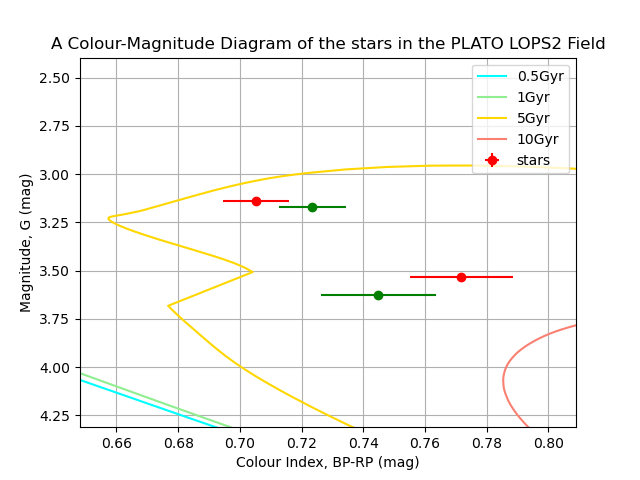

/tmp/ipykernel_271/2785428717.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo" (-> color='b'). The keyword argument will take precedence.
  plt.errorbar([ci.n for ci in colour_index_hot], [amG.n for amG in abs_mag_hot_G], c='r', label='stars', xerr=[ci.s for ci in colour_index_hot], yerr=[amG.s for amG in abs_mag_hot_G], fmt='bo')
/tmp/ipykernel_271/2785428717.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.errorbar([ci.n for ci in colour_index_faint], [amG.n for amG in abs_mag_faint_G], c='g', xerr=[ci.s for ci in colour_index_faint], yerr=[amG.s for amG in abs_mag_faint_G], fmt='ro')


In [11]:
#Plotting the CMD
plt.figure()
plt.errorbar([ci.n for ci in colour_index_hot], [amG.n for amG in abs_mag_hot_G], c='r', label='stars', xerr=[ci.s for ci in colour_index_hot], yerr=[amG.s for amG in abs_mag_hot_G], fmt='bo')
plt.errorbar([ci.n for ci in colour_index_faint], [amG.n for amG in abs_mag_faint_G], c='g', xerr=[ci.s for ci in colour_index_faint], yerr=[amG.s for amG in abs_mag_faint_G], fmt='ro')
plt.plot(BP_one-RP_one, G_one,c='aqua', label='0.5Gyr')
plt.plot(BP_two-RP_two, G_two,c='lightgreen', label='1Gyr')
plt.plot(BP_three-RP_three, G_three,c='gold', label='5Gyr')
plt.plot(BP_four-RP_four, G_four,c='salmon', label='10Gyr')
plt.gca().invert_yaxis()
plt.ylim(10,-2)
plt.xlim(-0.25,2.5)
plt.xlabel('Colour Index, BP-RP (mag)')
plt.ylabel('Magnitude, G (mag)')
plt.title('A Colour-Magnitude Diagram of the stars in the PLATO LOPS2 Field')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()